# Build and Test Clustering 

Using subject (genre), category, page counts, published date

#### Imports and Data 

In [31]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [32]:
df = pd.read_csv("../data/books.csv")
df["published_date"] = pd.to_datetime(df["published_date"], errors="coerce")
print(df.shape)
df.head()

(810, 11)


,title,authors,publisher,subject,categories,maturityRating,page_count,average_rating,ratings_count,published_date,description
0,The Dream of the Celt,Mario Vargas Llosa,Macmillan + ORM,fiction,Fiction,NOT_MATURE,455,0.0,0,2012-06-05,"This ""vast and intriguing novel"" explores the ..."
1,The Natural,Bernard Malamud,Macmillan,fiction,Fiction,NOT_MATURE,250,0.0,0,1952-01-01,Story of a baseball player's record-shattering...
2,Journey to the Center of the Earth,Jules Verne,Bantam,fiction,Fiction,NOT_MATURE,242,3.5,3,2006-04-25,The intrepid Professor Lindenbrock embarks upo...
3,Mysteries,Knut Hamsun,Penguin,fiction,Fiction,NOT_MATURE,356,4.0,3,2001-01-01,The first complete English translation of the ...
4,Cat's Cradle,Kurt Vonnegut,Dial Press Trade Paperback,fiction,Fiction,NOT_MATURE,308,4.0,147,1998-09-08,“A free-wheeling vehicle . . . an unforgettabl...


#### Publishing Year extract 

In [33]:
#just get year 
df["publish_year"] = df["published_date"].dt.year

In [34]:
#check for missing dates 
df["publish_year"].isna().sum()

#if missing dates, fill with median year
median_year = df["publish_year"].median()
df["publish_year"] = df["publish_year"].fillna(median_year)

In [35]:
#year range 
print(f"publish year range: {df['publish_year'].min()} - {df['publish_year'].max() }")

publish year range: 1951 - 2026


#### normalize page counts and publish year 

In [36]:
scaler = MinMaxScaler()

#scale to be between 0 and 1 for clustering
# df["page_count_scaled"] = scaler.fit_transform(df[["page_count"]])
# df["publish_year_scaled"] = scaler.fit_transform(df[["publish_year"]])
df[["page_count_scaled", "publish_year_scaled"]] = scaler.fit_transform(df[["page_count", "publish_year"]])

#confirm 
print(df[["page_count_scaled", "publish_year_scaled"]].describe())


       page_count_scaled  publish_year_scaled
count         810.000000           810.000000
mean            0.141896             0.660165
std             0.078121             0.215998
min             0.000000             0.000000
25%             0.094881             0.533333
50%             0.129422             0.706667
75%             0.172493             0.840000
max             1.000000             1.000000


#### Encode genres and categories

In [37]:
#turn genre into indicator columns with one hot encoding
subject_dummies = pd.get_dummies(df["subject"], prefix="subject")
subject_dummies.head()

,subject_fantasy,subject_fiction,subject_historical fiction,subject_mystery,subject_nonfiction,subject_romance,subject_science,subject_science fiction,subject_self help,subject_thriller
0,False,True,False,False,False,False,False,False,False,False
1,False,True,False,False,False,False,False,False,False,False
2,False,True,False,False,False,False,False,False,False,False
3,False,True,False,False,False,False,False,False,False,False
4,False,True,False,False,False,False,False,False,False,False


In [38]:
#turn categories into indicator columns with one hot encoding

#first deal with instances of list of categories 
category_dummies = df["categories"].str.get_dummies(sep=",")
#add prefix to columns
category_dummies.columns = ["category_"+col for col in category_dummies.columns]
category_dummies.head()

,category_ 1921-1922,category_ Ancient,category_ Calif.),"category_ Charlie ""Bird"" (Fictitious character)",category_ English,category_ Mind & Spirit,category_ N.Y.),category_ Swedish,category_ Temperance (Fictitious character),category_ The,...,category_Romance fiction,category_Science,category_Self,category_Self-Help,category_Social Science,category_Technology & Engineering,category_Thriller - Fiction,category_Travel,category_Unknown,category_Young Adult Fiction
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


#### combine all features

In [39]:
#keep categories that appear in at least 5 books 
cat_columns = category_dummies.columns.tolist()
keep_cats = [col for col in cat_columns if category_dummies[col].sum() >= 5]

print("before category columns: ", len(cat_columns))
print("after category columns: ", len(keep_cats))

before category columns:  142
after category columns:  26


In [40]:
features = pd.concat([
    df[["page_count_scaled", "publish_year_scaled"]],
    subject_dummies,
    category_dummies[keep_cats]
], axis = 1)

print("features shape: ", features.shape)
features.head()

features shape:  (810, 38)


,page_count_scaled,publish_year_scaled,subject_fantasy,subject_fiction,subject_historical fiction,subject_mystery,subject_nonfiction,subject_romance,subject_science,subject_science fiction,...,category_Language Arts & Disciplines,category_Literary Criticism,category_Medical,category_Nature,category_Philosophy,category_Psychology,category_Science,category_Self-Help,category_Social Science,category_Unknown
0,0.184353,0.813333,False,True,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
1,0.099043,0.013333,False,True,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
2,0.095714,0.733333,False,True,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
3,0.143154,0.666667,False,True,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
4,0.123179,0.626667,False,True,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0


In [41]:
#check null 
features.isna().sum().sum()

np.int64(0)

### K Means

Find K value - elbow method 

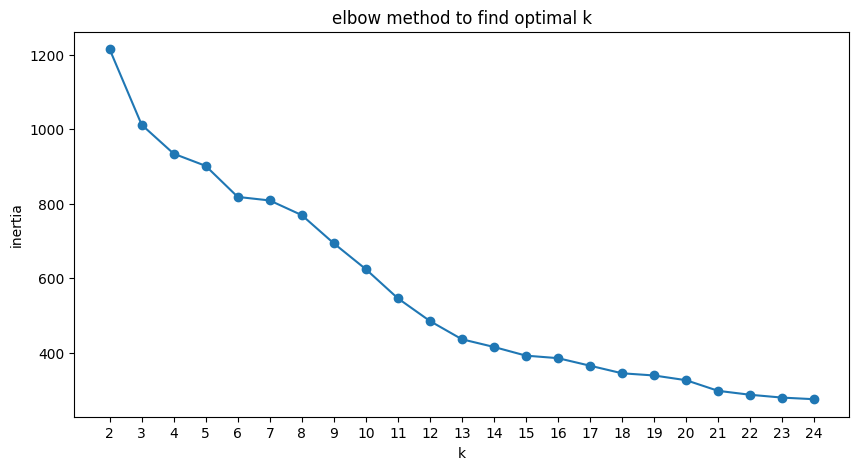

In [42]:
inertia = [] #track how tight clusters are
k_range = range(2, 25)

#test out ks 
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=123)
    kmeans.fit(features)
    inertia.append(kmeans.inertia_)

#plot inertia to find elbow point
plt.figure(figsize=(10,5))
plt.plot(k_range, inertia, marker="o")
plt.title("elbow method to find optimal k")
plt.xlabel("k")
plt.ylabel("inertia")
plt.xticks(k_range)
plt.show()

somewhere in k = [11, 14]

In [44]:
for k in [11, 12, 13, 14]:
    kmeans = KMeans(n_clusters=k, random_state=123)
    kmeans.fit(features)
    df[f"cluster_{k}"] = kmeans.labels_
    print(f"\n{k} clusters")
    print(df[f"cluster_{k}"].value_counts().sort_index())


11 clusters
cluster_11
0       6
1      87
2      79
3      87
4      58
5      98
6      74
7      13
8      79
9      88
10    141
Name: count, dtype: int64

12 clusters
cluster_12
0      6
1     87
2     76
3     87
4     76
5     98
6     74
7     13
8     79
9     73
10    68
11    73
Name: count, dtype: int64

13 clusters
cluster_13
0      6
1     87
2     76
3     87
4     54
5     98
6     74
7     12
8     79
9     73
10    68
11    54
12    42
Name: count, dtype: int64

14 clusters
cluster_14
0      6
1     87
2     76
3     29
4     54
5     98
6     74
7     12
8     79
9     73
10    68
11    54
12    42
13    58
Name: count, dtype: int64


k = 11 best 


In [52]:
kmeans = KMeans(n_clusters=11, random_state=123, n_init=10)
kmeans.fit(features)
df["cluster"] = kmeans.labels_

print(df["cluster"].value_counts().sort_index())

cluster
0      88
1      79
2      58
3      71
4     100
5      87
6      76
7      86
8      76
9      51
10     38
Name: count, dtype: int64


### PCA 

In [53]:
pca = PCA(n_components=2, random_state=123)
pca_features = pca.fit_transform(features)

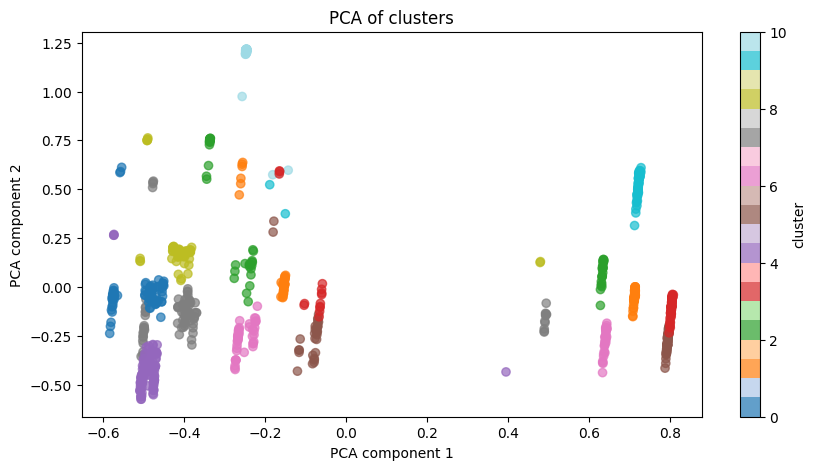

In [54]:
#plot PCA components colored by cluster
plt.figure(figsize=(10,5))
scatter = plt.scatter(
    pca_features[:,0], #x axis , first PCA component
    pca_features[:,1], #y axis, second PCA component
    c=df["cluster"],  # color by cluster assignment
    cmap="tab20", #20 distinct colors
    alpha=0.7
)
plt.colorbar(scatter, label="cluster")
plt.title("PCA of clusters")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.show()

look at each cluster 

In [55]:
for i in range(11):
    print(f"cluster {i}")
    cluster_books = df[df["cluster"] == i]
    print("subjects: ", cluster_books["subject"].value_counts().to_dict())
    print("categories: ", cluster_books["categories"].value_counts().to_dict())
    print("titles: ", cluster_books["title"].tolist()[:5]) 


cluster 0
subjects:  {'science': 88}
categories:  {'Science': 29, 'Nature': 9, 'Biography & Autobiography': 6, 'Medical': 6, 'Business & Economics': 4, 'Technology & Engineering': 4, 'Mathematics': 3, 'Computers': 3, 'History': 3, 'Unknown': 3, 'Social Science': 2, 'Language Arts & Disciplines': 2, 'Philosophy': 2, 'Gardening': 2, 'Health & Fitness': 2, 'Juvenile Nonfiction': 1, 'Art': 1, 'Biography': 1, 'Political Science': 1, 'Psychology': 1, 'Miniature books': 1, 'Civilization, Ancient': 1, 'Body, Mind & Spirit': 1}
titles:  ['Silent Spring', 'Longitude', 'The Beginning of the Age of Mammals', 'On the Revolutions of Heavenly Spheres', 'Conservation Biology for All']
cluster 1
subjects:  {'thriller': 79}
categories:  {'Fiction': 42, 'Unknown': 6, 'Adventure stories': 3, 'Thriller - Fiction': 2, 'Detective and mystery stories': 2, 'Brothers': 2, 'Art museum curators': 1, 'Parker, Charlie "Bird" (Fictitious character)': 1, 'Large print books': 1, 'JUVENILE FICTION': 1, 'Ex-convicts': 1

#### Save Model 

In [56]:
import joblib

#save model 
joblib.dump(kmeans, "../data/kmeans_model.pkl")

#save feature matrix column names 
joblib.dump(features.columns.tolist(), "../data/feature_columns.pkl")

#save scalar for page count and publish year 
joblib.dump(scaler, "../data/scaler.pkl")

#save clustered data
df.to_csv("../data/books.csv", index=False)


